## Preparing the dataset for RF

Best results (pearson correlation) for window size: variable/size/p correlation

NDVI class 1      /  15  /  -0.72

NDVI class 0.5    /  6   /   0.02

NDWI class 1      /  8   /  -0.1

Volumen veg       /  7   /  -0.61

volumen edif      /  9   /   0.42

area edif         /  8   /   0.50

elev mean         /  1   /  -0.15

slope mean        /  100 /  -0.65

northness         /  60  /  -0.28

eastness          /  11  /  -0.17

In [16]:
import os
import numpy as np
import rasterio
from rasterio import mask
import geopandas as gpd
import matplotlib.pyplot as plt


In [22]:
# variables
lst_cropped_path = '../../datos-notebooks/0.LST/LST_cropped_celsius.tif'
ndvi_1 = '../../datos-notebooks/1.land-cover/moving-windows/ndvi/Class_1_window15.tif'
ndwi_1 = '../../datos-notebooks/1.land-cover/moving-windows/ndwi/Class_1_window8.tif'
veg_vol = '../../datos-notebooks/2.objects-height/moving-windows/tree-volume/trees_window7.tif'
built_vol = '../../datos-notebooks/2.objects-height/moving-windows/building-volume/buildings_window9.tif'
built_area = '../../datos-notebooks/2.objects-height/moving-windows/building-area/building_area_window8.tif'
mean_elev = '../../datos-notebooks/3.topography/dtm_30m/elev_mean/elev_mean_win1.tif'
mean_slope = '../../datos-notebooks/3.topography/dtm_30m/slope_mean/slope_mean_win100.tif'
northness = '../../datos-notebooks/3.topography/dtm_30m/northness/northness_win60.tif'

# City Boundary
bound = "../../datos-notebooks/bologne_boundary.geojson"
gdf = gpd.read_file(bound)

output_dir = '../../datos-notebooks/4.LST-prediction/'
os.makedirs(output_dir, exist_ok=True)

In [24]:
# Dictionary of rasters: variable name -> path
rasters_dict = {
    "lst_cropped": lst_cropped_path,
    "ndvi_1": ndvi_1,
    "ndwi_1": ndwi_1,
    "veg_vol": veg_vol,
    "built_vol": built_vol,
    "built_area": built_area,
    "mean_elev": mean_elev,
    "mean_slope": mean_slope,
    "northness": northness
}

# Convert city boundary to raster CRS
with rasterio.open(lst_cropped_path) as src_ref:
    boundary = gdf.to_crs(src_ref.crs)

geoms = [boundary.unary_union.__geo_interface__]

# Dictionary to store clipped rasters in memory
clipped_rasters = {}

for var_name, rpath in rasters_dict.items():
    with rasterio.open(rpath) as src:
        # crop=True ensures the raster is literally cut to the bounding box
        out_image, out_transform = mask.mask(
            src, geoms, crop=True, nodata=np.nan
        )
        out_image = out_image.astype("float32")
        out_image[out_image == src.nodata] = np.nan

        # Save clipped raster and metadata in memory
        out_meta = src.meta.copy()
        out_meta.update({
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
            "dtype": "float32",
            "nodata": np.nan
        })

        clipped_rasters[var_name] = {
            "array": out_image,
            "meta": out_meta
        }

# Ejemplo: acceso al array de LST recortado
lst_array = clipped_rasters["lst_cropped"]["array"]
lst_meta = clipped_rasters["lst_cropped"]["meta"]


C:\Users\guada\AppData\Local\Temp\ipykernel_5152\965150672.py:18: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geoms = [boundary.unary_union.__geo_interface__]


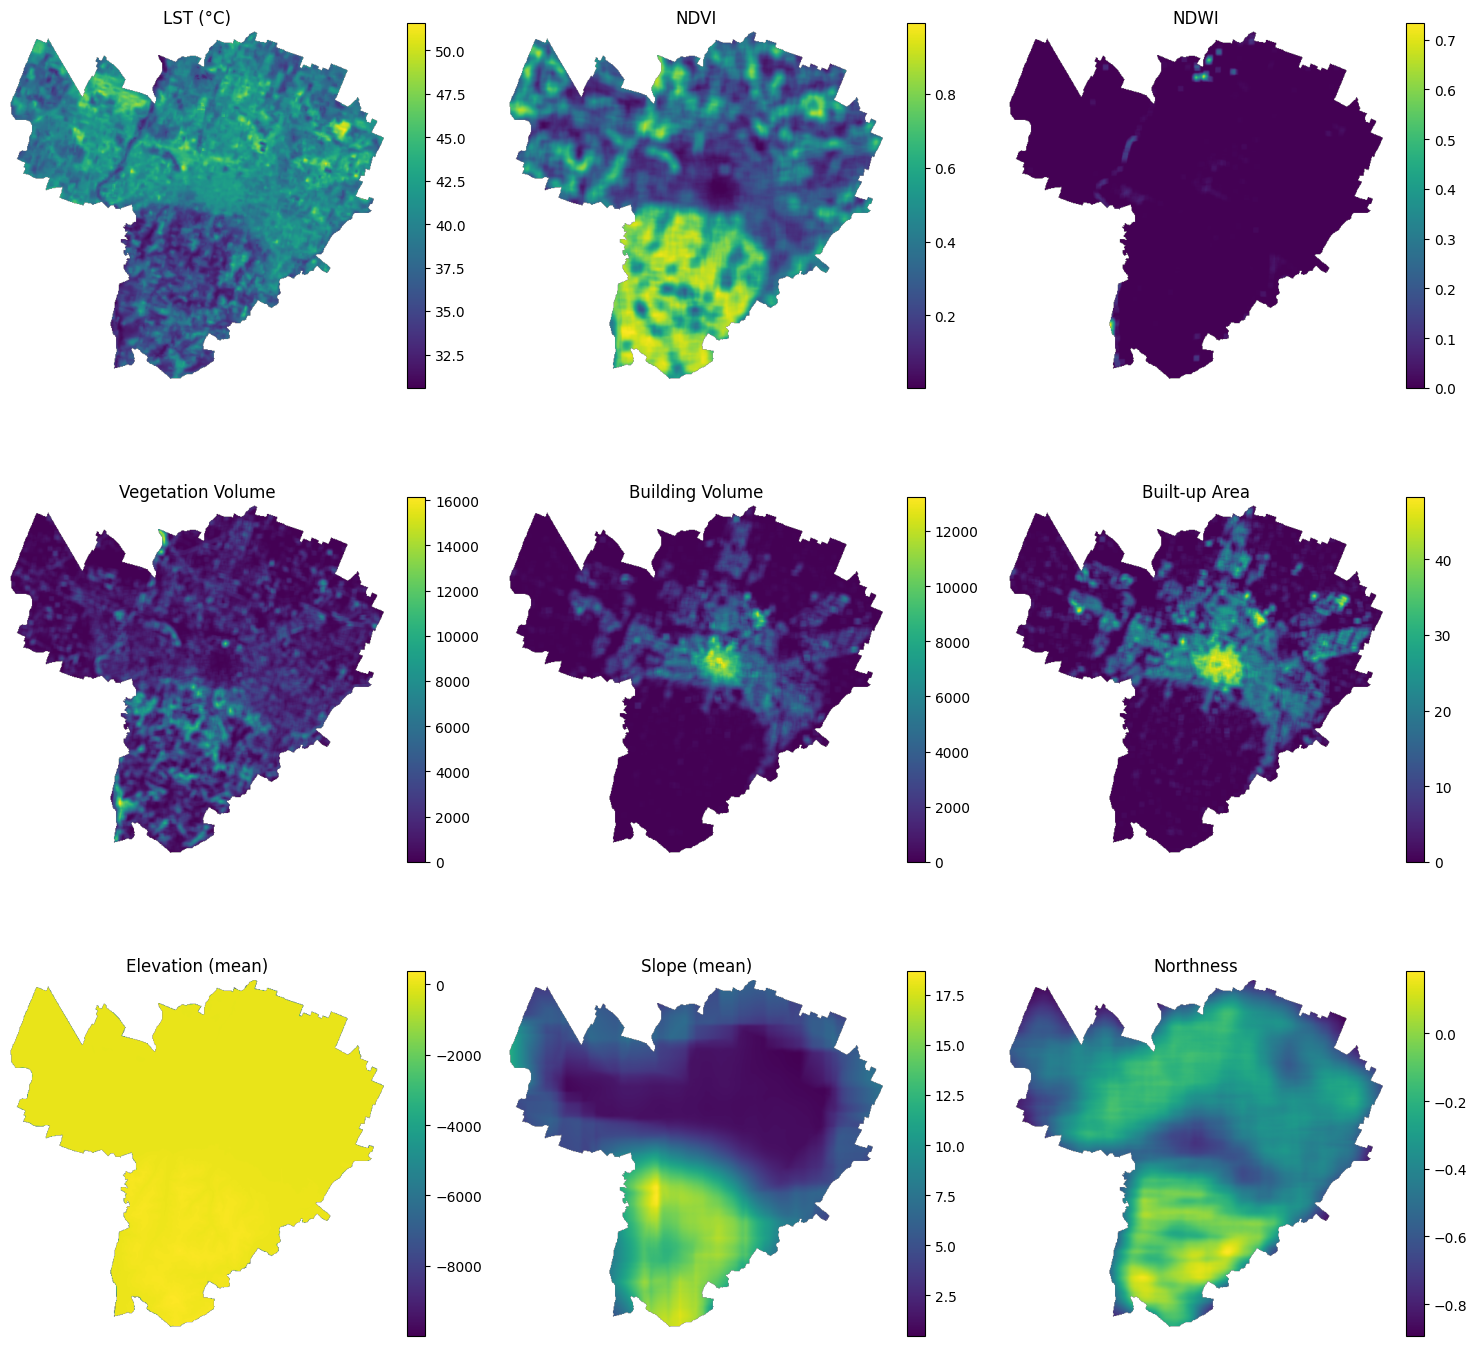

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# List of variable names and titles
var_names = [
    "lst_cropped", "ndvi_1", "ndwi_1",
    "veg_vol", "built_vol", "built_area",
    "mean_elev", "mean_slope", "northness"
]

titles = [
    "LST (°C)", "NDVI", "NDWI",
    "Vegetation Volume", "Building Volume", "Built-up Area",
    "Elevation (mean)", "Slope (mean)", "Northness"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, var in enumerate(var_names):
    arr = clipped_rasters[var]["array"][0]  # take first band
    arr = np.where(np.isnan(arr), np.nan, arr)  # ensure nodata is nan

    im = axes[i].imshow(arr, cmap='viridis')
    axes[i].set_title(titles[i])
    axes[i].axis('off')

    fig.colorbar(im, ax=axes[i], shrink=0.7)

plt.tight_layout()
plt.show()


In [27]:
import numpy as np

# Get the array of mean elevation
elev_array = clipped_rasters["mean_elev"]["array"][0]  # first band

# Compute min and max ignoring NaN
min_elev = np.nanmin(elev_array)
max_elev = np.nanmax(elev_array)

print("Minimum elevation:", min_elev)
print("Maximum elevation:", max_elev)


Minimum elevation: -9999.0
Maximum elevation: 390.1744
